# Predicting Apartment Prices in Buenos Aires

### A feature-by-feature exploration leading to a regularized linear model

Buenos Aires has one of Latin America's most active real estate markets. This notebook walks through predicting apartment prices in Capital Federal using size, location, and neighborhood - starting from raw data, cleaning it methodically, and building up to a Ridge regression pipeline. Each step is justified by what the data actually shows.


## 1. Imports


In [3]:



import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline



## 2. Data Loading & Wrangling

### 2.1 The wrangle function

The wrangle function does all the heavy lifting in one place. Rather than scattering cleaning steps throughout the notebook, every decision made during exploration (sections 3–6) feeds back into this function. Think of it as the living record of what we learned.


In [4]:
def wrangle(filepath):
    # Reading CSV file
    df = pd.read_csv(filepath)

    # Subsetting data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]
    
    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # Get place name
    df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand=True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)
    
    # Drop features with high null counts
    df.drop(columns=["expenses","floor"], inplace=True)
    
    # Drop features with low and high cardinality
    df.drop(columns=["operation","currency","property_type","properati_url"],inplace=True)
    
    # Drop leaky columns
    df.drop(columns=["price","price_aprox_local_currency","price_per_m2","price_usd_per_m2"],inplace=True)
    
    # Drop columns with multicollinearity
    df.drop(columns=["surface_total_in_m2","rooms"],inplace=True)
    
    return df

### 2.2 Load the data


In [5]:
df = wrangle("buenos-aires-real-estate.csv")
df.head()

,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,Constitución
41,90000.0,50.0,-34.610610,-58.412511,Once


## 3. Exploratory Data Analysis

Before touching the model, we look at each feature on its own - distributions, relationships with price, and anything that needs fixing.

### 3.1 Size (`surface_covered_in_m2`)


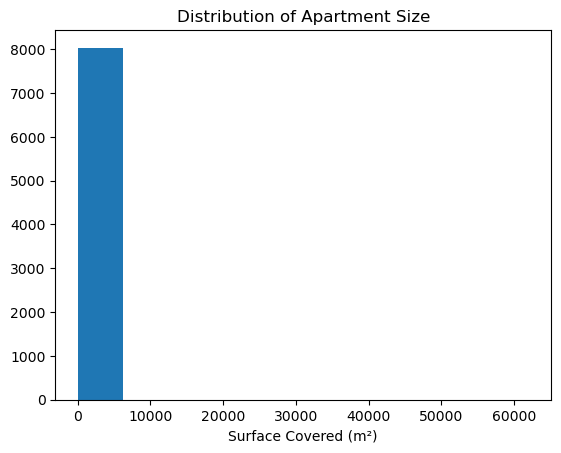

In [12]:
plt.hist(df["surface_covered_in_m2"])
plt.xlabel("Surface Covered (m²)")

plt.title("Distribution of Apartment Size");


In [13]:
df["surface_covered_in_m2"].describe()

count     8036.000000
mean        67.410154
std        697.311110
min          0.000000
25%         37.000000
50%         49.000000
75%         72.000000
max      62034.000000
Name: surface_covered_in_m2, dtype: float64

Extreme values on both ends stretch the distribution. We'll trim the outer 10% on each side.


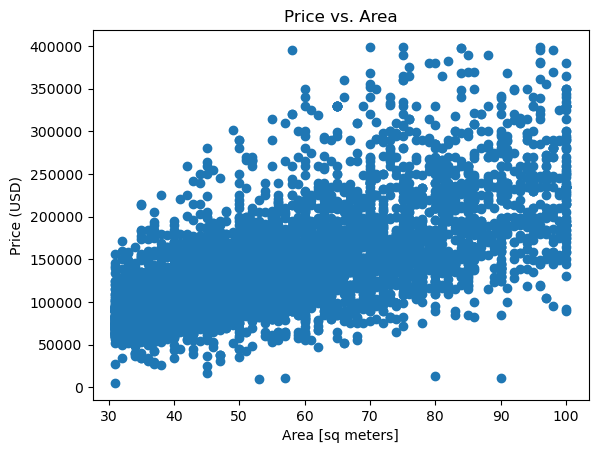

In [19]:
# Relationship between size and price 
plt.scatter(x=df["surface_covered_in_m2"], y=df["price_aprox_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price (USD)")
plt.title("Price vs. Area");

### 3.2 Location (`lat`/`lon`)

Coordinates are stuck together in a single string column - we need to split them before they're usable.


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6507 entries, 4 to 43021
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   6507 non-null   object 
 1   property_type               6507 non-null   object 
 2   place_with_parent_names     6507 non-null   object 
 3   lat-lon                     6247 non-null   object 
 4   price                       6507 non-null   float64
 5   currency                    6507 non-null   object 
 6   price_aprox_local_currency  6507 non-null   float64
 7   price_aprox_usd             6507 non-null   float64
 8   surface_total_in_m2         4682 non-null   float64
 9   surface_covered_in_m2       6507 non-null   float64
 10  price_usd_per_m2            4466 non-null   float64
 11  price_per_m2                6507 non-null   float64
 12  floor                       1884 non-null   float64
 13  rooms                       5232 non-

In [21]:
df["lat-lon"].head(10)

4     -34.5846508988,-58.4546932614
9            -34.6389789,-58.500115
29            -34.615847,-58.459957
40          -34.6252219,-58.3823825
41          -34.6106102,-58.4125107
48          -34.6038236,-58.4272911
58            -34.586103,-58.423963
62    -34.6265182557,-58.4724630529
70          -34.5620844,-58.4566864
72            -34.648143,-58.524277
Name: lat-lon, dtype: object

### 3.3 Neighborhood

Neighborhood is buried inside a string. We extract position [3] to get just the district name.


In [22]:
# What the raw column looks like
df["place_with_parent_names"].head(5)

4        |Argentina|Capital Federal|Chacarita|
9       |Argentina|Capital Federal|Villa Luro|
29       |Argentina|Capital Federal|Caballito|
40    |Argentina|Capital Federal|Constitución|
41            |Argentina|Capital Federal|Once|
Name: place_with_parent_names, dtype: object

### 3.4 Data Quality Checks

**Missing values** - checking for columns with high null counts.


In [24]:
# Columns with any missing values
df.isnull().sum()/len(df)

operation                     0.000000
property_type                 0.000000
place_with_parent_names       0.000000
lat-lon                       0.039957
price                         0.000000
currency                      0.000000
price_aprox_local_currency    0.000000
price_aprox_usd               0.000000
surface_total_in_m2           0.280467
surface_covered_in_m2         0.000000
price_usd_per_m2              0.313662
price_per_m2                  0.000000
floor                         0.710466
rooms                         0.195943
expenses                      0.736591
properati_url                 0.000000
dtype: float64

`expenses` and `floor` have high null counts and are dropped.

**Cardinality** - checking for columns that are too sparse or too granular to be useful.


In [26]:
# Cardinality of categorical columns
df.select_dtypes(include="object").nunique()

operation                     1
property_type                 1
place_with_parent_names      57
lat-lon                    4410
currency                      2
properati_url              6507
dtype: int64

`operation`, `currency`, `property_type`, and `properati_url` are dropped - too low or too high cardinality to add signal.

**Leakage** - checking for columns derived from the target.


In [31]:
# Columns that would constitute leakage
sorted(df.columns)

['lat',
 'lon',
 'neighborhood',
 'price',
 'price_aprox_local_currency',
 'price_aprox_usd',
 'price_per_m2',
 'price_usd_per_m2',
 'rooms',
 'surface_covered_in_m2',
 'surface_total_in_m2']

These columns are derived from the target. Including them would be cheating. `price`, `price_aprox_local_currency`, `price_per_m2`, and `price_usd_per_m2` are dropped.

**Multicollinearity** - checking for redundant numeric features.


In [39]:
# Checking for multicollinearity
corr = df.select_dtypes(include="number").drop(columns='price_aprox_usd').corr()
corr

,surface_total_in_m2,surface_covered_in_m2,rooms,lat,lon
surface_total_in_m2,1.000000,0.732010,0.590365,0.069018,0.025107
surface_covered_in_m2,0.732010,1.000000,0.781170,0.027821,0.039916
rooms,0.590365,0.781170,1.000000,-0.049771,0.036120
lat,0.069018,0.027821,-0.049771,1.000000,-0.263669
lon,0.025107,0.039916,0.036120,-0.263669,1.000000


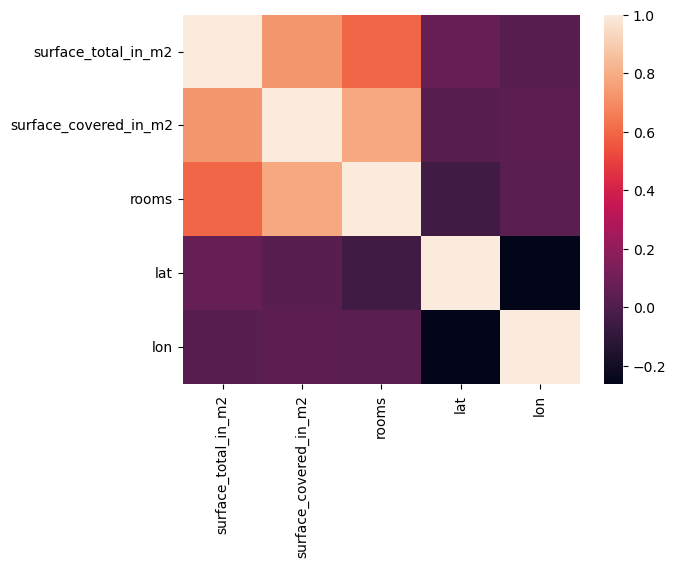

In [42]:
sns.heatmap(corr);

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6507 entries, 4 to 43021
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6507 non-null   float64
 1   surface_total_in_m2    4682 non-null   float64
 2   surface_covered_in_m2  6507 non-null   float64
 3   rooms                  5232 non-null   float64
 4   lat                    6247 non-null   float64
 5   lon                    6247 non-null   float64
 6   neighborhood           6507 non-null   object 
dtypes: float64(6), object(1)
memory usage: 406.7+ KB


`surface_total_in_m2` and `rooms` are too correlated with our size feature to add signal - both are dropped.


## 4. Train/Test Split

We hold out 20% of the data now and don't touch it again until final evaluation. This is the only way to get an honest measure of how the model generalizes.


In [6]:
target = "price_aprox_usd"
features = ["surface_covered_in_m2", "lat", "lon", "neighborhood"]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

Training set: (5205, 4)
Test set:     (1302, 4)


## 5. Baseline

Before any model, we ask: what's the dumbest possible prediction? Predicting the mean price every time gives us a floor. If our model can't beat this, it's not useful.


In [10]:
y_pred_baseline = [y_train.mean()] * len(y_train)
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)

print(f"Mean apartment price: ${y_train.mean()}")
print(f"Baseline MAE:         ${baseline_mae:}")

Mean apartment price: $133158.7816945245
Baseline MAE:         $44845.53582642715


## 6. Model - Ridge Pipeline

We need to handle three things before fitting: encode the neighborhood strings into binary columns (`OneHotEncoder`), fill the handful of missing coordinates (`SimpleImputer` with median), and then fit a Ridge regression.

Linear regression with many one-hot neighborhood columns risks overfitting - small datasets with high-dimensional categorical encodings tend to latch onto noise. Ridge adds L2 regularization, shrinking coefficients toward zero without dropping them entirely, which gives better generalization without needing to manually select neighborhoods.


In [11]:

model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(strategy="median"),
    Ridge(alpha=1)
)

model.fit(X_train, y_train)



C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('simpleimputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,['neighborhood']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


## 7. Evaluation

How much are we off by on average, and does the model hold up on data it's never seen?


In [12]:
y_pred_training = model.predict(X_train)
y_pred_test = model.predict(X_test)

training_mae =mean_absolute_error(y_train,y_pred_training)
test_mae = mean_absolute_error(y_test, y_pred_test)
print("Training MAE:", round(training_mae, 2))
print("Test MAE:", round(test_mae, 2))

Training MAE: 24172.47
Test MAE: 25360.04


Training and test Mae are within 1,200 of each other - the regularization is keeping the model honest across the neighborhood columns, with no sign of overfitting. Both also land well below the baseline MAE of 44,845.54, a roughly 43% reduction in error.

## 8. Model Interpretation

MAE tells us how accurate - coefficients tell us what the model learned. We pull the feature importances from the fitted Ridge step to see which neighborhoods and features move the price needle most.


In [67]:


intercept = model.named_steps["ridge"].intercept_
coefficients = model.named_steps["ridge"].coef_
feature_names = model.named_steps["onehotencoder"].get_feature_names_out()


In [68]:
feat_imp = pd.Series(coefficients, index=feature_names).sort_values(key=abs)
feat_imp

neighborhood_Chacarita                  197.182029
neighborhood_Parque Chas               -276.169296
neighborhood_Villa Devoto               767.455121
neighborhood_Villa Luro                -804.040954
neighborhood_Abasto                    1193.628743
neighborhood_San Telmo                -1651.182331
neighborhood_Villa General Mitre      -2148.217645
surface_covered_in_m2                  2205.536061
neighborhood_Parque Centenario        -2422.031686
neighborhood_Boedo                     2460.359951
neighborhood_Paternal                 -3583.288222
neighborhood_Almagro                  -3619.372677
neighborhood_Villa del Parque         -3814.460998
neighborhood_Monte Castro             -3976.017469
neighborhood_Villa Ortuzar             4047.363741
neighborhood_Villa Crespo              4635.776714
neighborhood_San Cristobal            -5057.545265
neighborhood_Villa Santa Rita         -5645.717744
neighborhood_                         -6909.450778
neighborhood_Tribunales        

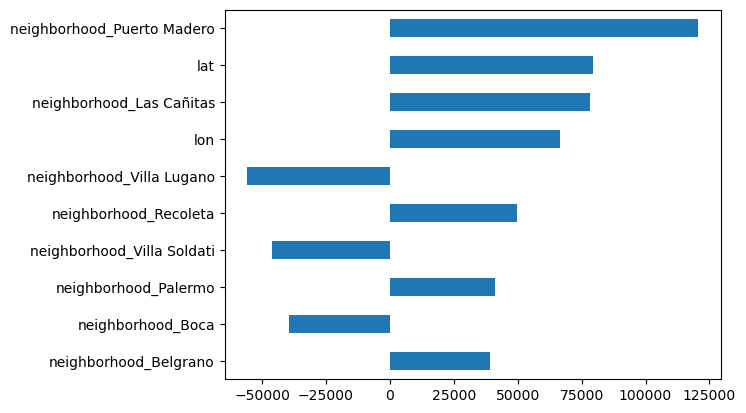

In [69]:
feat_imp.tail(10).plot(kind="barh");

Among the neighborhood dummies specifically (excluding `lat`/`lon`, which are continuous and dominate by scale), Recoleta (+49,794), Puerto Madero (+120,551), and Las Cañitas (+78,188) carry the strongest positive coefficients - all well-known as some of the most expensive areas in the city. On the other end, Villa Lugano (-55,814), Boca (-39,303), and Pompeya (-38,916) pull price down the most, consistent with how these areas are generally perceived in the local market. `surface_covered_in_m2` itself adds roughly +2,206 per square meter, holding location constant

## 9. Prediction Function

Wrap the model in a simple function so it can be called with raw inputs without worrying about DataFrame construction.


In [70]:
def make_prediction(area, lat, lon, neighborhood):
    data = {
        "surface_covered_in_m2": area,
        "lat": lat,
        "lon": lon,
        "neighborhood": neighborhood
    }
    df = pd.DataFrame(data, index=[0])
    prediction = model.predict(df).round(2)[0]
    return f"Predicted apartment price: ${prediction}"

make_prediction(110, -34.60, -58.46, "Villa Crespo")

'Predicted apartment price: $249382.21'